# Algorithm of Choice: NewtonW on Rosenbrock

**Algorithm:** NewtonW (Modified Newton with Wolfe line search)

**Optimal Parameters from Big Question:** $(c_1, c_2) = (0.05, 0.5)$, $\alpha_0 = 1.0$

This notebook runs NewtonW on both Rosenbrock problems (n=2 and n=100) and reports:
- Iterations to convergence
- Function/gradient evaluations
- CPU time
- Convergence plots

In [1]:
import csv
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# The deliverables/ folder contains algorithms.py, functions.py, and
# optSolver_Bazinga_Trio.py directly, so add the notebook's own directory
# to sys.path.
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import functions
import optSolver_Bazinga_Trio as _optSolver_module


def optSolver(problem, method, options):
    """Internal wrapper that returns the full 4-tuple (x, f, f_hist, alpha_hist)
    used by this notebook's convergence plots. The spec-compliant grader
    entrypoint is ``optSolver_Bazinga_Trio(problem, method, options)`` which
    returns only (x, f).
    """
    return _optSolver_module.Solver(problem, method, options)


print(f"Using solver from: {_optSolver_module.__file__}")

Using solver from: /Users/handsomeye/all_kinds_pj/ioe511/IOE511_Project/deliverables/optSolver_Bazinga_Trio.py


In [2]:
# Problem/Method/Options containers
class Problem:
    """Wraps an optimization problem and counts f/g/H evaluations."""
    def __init__(self, name, x0, func=None, grad=None, hess=None):
        self.name = name
        self.x0 = np.asarray(x0, dtype=float)
        self._func = func
        self._grad = grad
        self._hess = hess
        self.f_eval = 0
        self.g_eval = 0
        self.h_eval = 0

        # Fallback for quick single-problem debugging.
        if self._func is None or self._grad is None or self._hess is None:
            match name:
                case "Rosenbrock":
                    self._func = functions.Rosenbrock_func
                    self._grad = functions.Rosenbrock_grad
                    self._hess = functions.Rosenbrock_hess
                case _:
                    raise ValueError(f"problem '{name}' not defined")

    def compute_f(self, x):
        self.f_eval += 1
        return float(self._func(np.asarray(x, dtype=float)))

    def compute_g(self, x):
        self.g_eval += 1
        return np.asarray(self._grad(np.asarray(x, dtype=float)), dtype=float)

    def compute_H(self, x):
        self.h_eval += 1
        return np.asarray(self._hess(np.asarray(x, dtype=float)), dtype=float)


class Method:
    """Container for algorithm name and option overrides."""
    def __init__(self, name, **options):
        self.name = name
        self.options = options


class Options:
    """Solver options bag."""
    def __init__(self, term_tol=1e-6, max_iterations=1000, **kwargs):
        self.term_tol = term_tol
        self.max_iterations = max_iterations
        for key, value in kwargs.items():
            setattr(self, key, value)

In [3]:
# Run NewtonW on Rosenbrock problems
def run_algorithm_of_choice(problem_name, n):
    """Run NewtonW on Rosenbrock(n) with optimal parameters.
    
    Args:
        problem_name: "P7_rosenbrock_2" or "P8_rosenbrock_100"
        n: dimension (2 or 100)
    
    Returns:
        dict with performance metrics and convergence history
    """
    # Set up initial point
    x0 = np.ones(n)
    x0[0] = -1.2

    # Create problem object
    problem = Problem(
        name=problem_name,
        x0=x0,
        func=functions.Rosenbrock_func,
        grad=functions.Rosenbrock_grad,
        hess=functions.Rosenbrock_hess,
    )

    # Algorithm of choice: NewtonW with optimal parameters from Big Question
    method = Method(
        "NewtonW",
        alpha0=1.0,           # initial step size
        c1_ls=0.05,           # Armijo parameter (optimal from Big Question)
        c2_ls=0.5,            # Wolfe curvature parameter (optimal from Big Question)
        tau=0.5,              # backtracking reduction (not used with Wolfe, but for safety)
    )

    # Global solver options
    options = Options(
        term_tol=1e-6,
        max_iterations=1000,
        c1_ls=0.05,
        c2_ls=0.5,
    )

    # Run the solver and time it
    print(f"\n{'='*70}")
    print(f"Running NewtonW on {problem_name} (n={n})")
    print(f"Optimal parameters: (c1_ls, c2_ls) = ({options.c1_ls}, {options.c2_ls})")
    print(f"{'='*70}")

    t0 = time.perf_counter()
    try:
        result = optSolver(problem, method, options)
        if len(result) == 4:
            x_final, f_final, f_hist, alpha_hist = result
        else:
            x_final, f_final, f_hist = result
            alpha_hist = []
        status = "success"
        error_msg = ""
    except Exception as exc:
        status = "failed"
        error_msg = str(exc)
        x_final = None
        f_final = np.nan
        f_hist = []
        alpha_hist = []

    cpu_sec = time.perf_counter() - t0
    iterations = max(len(f_hist) - 1, 0)

    # Compute gradient at final point
    grad_inf = np.nan
    if status == "success" and x_final is not None:
        grad_inf = np.linalg.norm(problem.compute_g(x_final), ord=np.inf)

    # Report results
    print(f"\nResults:")
    print(f"  Status:              {status}")
    if error_msg:
        print(f"  Error message:       {error_msg}")
    print(f"  Iterations:          {iterations}")
    print(f"  Function evaluations:{problem.f_eval}")
    print(f"  Gradient evaluations:{problem.g_eval}")
    print(f"  Hessian evaluations: {problem.h_eval}")
    print(f"  CPU time (seconds):  {cpu_sec:.6f}")
    print(f"  f(x_final):          {f_final:.10e}")
    print(f"  ||∇f(x_final)||_∞:   {grad_inf:.10e}")

    return {
        "problem": problem_name,
        "n": n,
        "status": status,
        "iterations": iterations,
        "f_eval": problem.f_eval,
        "g_eval": problem.g_eval,
        "h_eval": problem.h_eval,
        "cpu_sec": cpu_sec,
        "f_final": f_final,
        "grad_inf": grad_inf,
        "f_hist": f_hist,
        "alpha_hist": alpha_hist,
        "x_final": x_final,
        "error_msg": error_msg,
    }

In [4]:
# Run on both Rosenbrock problems
print("\n" + "="*70)
print("Algorithm of Choice: NewtonW on Rosenbrock Problems")
print("="*70)

results = []
results.append(run_algorithm_of_choice("P7_rosenbrock_2", 2))
results.append(run_algorithm_of_choice("P8_rosenbrock_100", 100))


Algorithm of Choice: NewtonW on Rosenbrock Problems

Running NewtonW on P7_rosenbrock_2 (n=2)
Optimal parameters: (c1_ls, c2_ls) = (0.05, 0.5)

Results:
  Status:              success
  Iterations:          20
  Function evaluations:26
  Gradient evaluations:27
  Hessian evaluations: 20
  CPU time (seconds):  0.000727
  f(x_final):          2.7542127055e-13
  ||∇f(x_final)||_∞:   8.2528808232e-07

Running NewtonW on P8_rosenbrock_100 (n=100)
Optimal parameters: (c1_ls, c2_ls) = (0.05, 0.5)

Results:
  Status:              success
  Iterations:          4
  Function evaluations:5
  Gradient evaluations:6
  Hessian evaluations: 4
  CPU time (seconds):  0.006701
  f(x_final):          3.9866238543e+00
  ||∇f(x_final)||_∞:   6.4532477406e-07



Generating convergence plots...


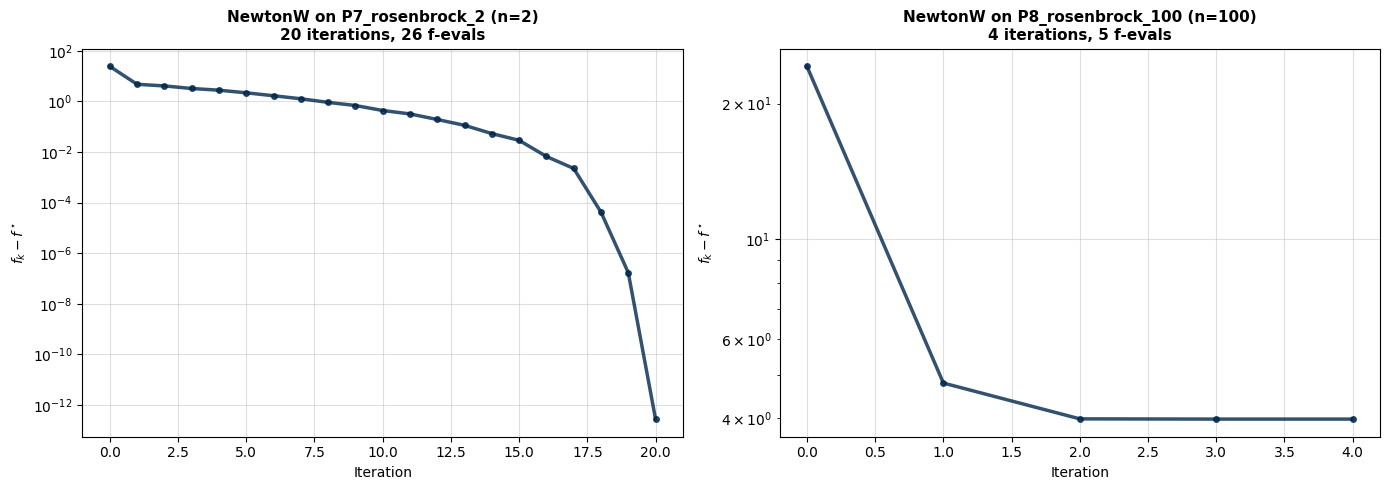

  Saved convergence plot: algorithm_performance/algorithm_of_choice_rosenbrock.png


In [5]:
from pathlib import Path

# Plot convergence for both problems
print("\nGenerating convergence plots...")

output_dir = Path("algorithm_performance")
output_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

for idx, res in enumerate(results):
    ax = axes[idx]
    if len(res["f_hist"]) > 1:
        f_hist = np.array(res["f_hist"], dtype=float)
        # Plot convergence to the known optimum f* = 0 for Rosenbrock
        yvals = np.maximum(f_hist, 1e-16)
        ax.semilogy(
            yvals,
            linewidth=2.5,
            color="#00274C",
            marker="o",
            markersize=4,
            alpha=0.8,
        )
        ax.set_title(
            f"NewtonW on {res['problem']} (n={res['n']})\n"
            f"{res['iterations']} iterations, {res['f_eval']} f-evals",
            fontsize=11,
            weight="semibold",
        )
    ax.set_xlabel("Iteration", fontsize=10)
    ax.set_ylabel(r"$f_k - f^\star$", fontsize=10)
    ax.grid(True, alpha=0.4)
    ax.set_facecolor("white")

plt.tight_layout()
plot_path = output_dir / "algorithm_of_choice_rosenbrock.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"  Saved convergence plot: {plot_path}")


In [6]:
# Summary table
print(f"\n{'='*70}")
print("Summary: NewtonW with Optimal Parameters (c1=0.05, c2=0.5)")
print(f"{'='*70}")
print(f"{'Problem':<30} {'n':>3} {'Iter':>6} {'f_eval':>8} {'CPU(s)':>10} {'Status':<10}")
print("-" * 70)
for res in results:
    print(f"{res['problem']:<30} {res['n']:>3} {res['iterations']:>6} "
          f"{res['f_eval']:>8} {res['cpu_sec']:>10.6f} {res['status']:<10}")
print("="*70)


Summary: NewtonW with Optimal Parameters (c1=0.05, c2=0.5)
Problem                          n   Iter   f_eval     CPU(s) Status    
----------------------------------------------------------------------
P7_rosenbrock_2                  2     20       26   0.000727 success   
P8_rosenbrock_100              100      4        5   0.006701 success   
